In [1]:
import gdsfactory as gf
from gsim.palace import DrivenSim
from ihp import PDK

PDK.activate()

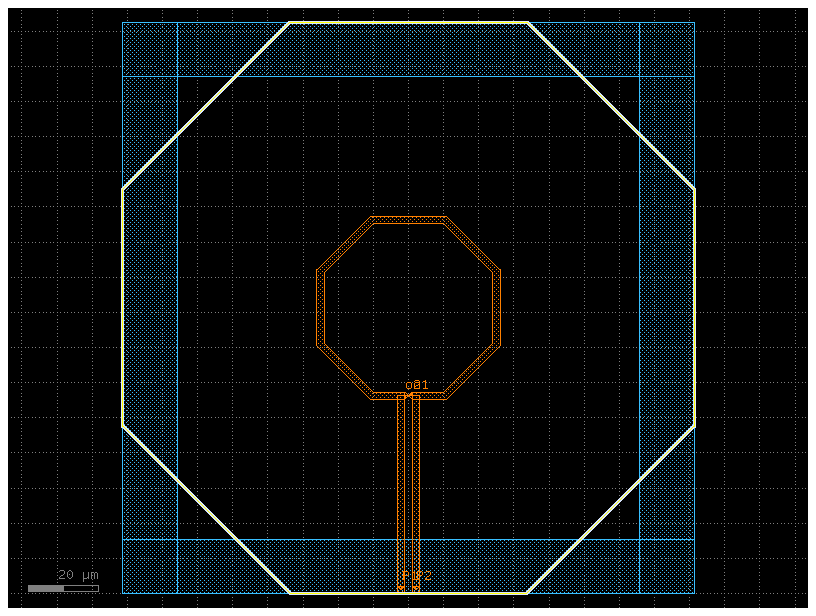

In [2]:
c = gf.components.inductor(
    width=2, 
    space=2.1, 
    diameter=50, 
    turns=1,
    layer_metal='TopMetal2drawing',
    layer_inductor='INDdrawing',
    layer_metal_pin='TopMetal2drawing',
    layers_no_fill=('NoMetFillerdrawing',)).copy()

#Define guard ring dimensions based on the inductor's bounding box
bbox = c.bbox()
xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top

margin_outer = 0.0 
margin_inner = -15.0 

ol, oright = xmin - margin_outer, xmax + margin_outer
ob, ot = ymin - margin_outer, ymax + margin_outer
il, ir = xmin - margin_inner, xmax + margin_inner
ib, it = ymin - margin_inner, ymax + margin_inner

w_v = il - ol  # Width vertical walls 
h_h = ot - it  # Height horizontal walls
over = 0.5     # Overlap for Gmsh to fuse the pieces

# Left wall 
c.add_ref(gf.components.rectangle(size=(w_v + over, ot - ob), layer='Metal1drawing', centered=True)).move((ol + w_v/2 + over/2, (ot + ob)/2))
# Right wall
c.add_ref(gf.components.rectangle(size=(w_v + over, ot - ob), layer='Metal1drawing', centered=True)).move((oright - w_v/2 - over/2, (ot + ob)/2))
# Top wall
c.add_ref(gf.components.rectangle(size=(oright - ol, h_h + over), layer='Metal1drawing', centered=True)).move(((oright + ol)/2, ot - h_h/2 - over/2))
# Bottom wall
c.add_ref(gf.components.rectangle(size=(oright - ol, h_h + over), layer='Metal1drawing', centered=True)).move(((oright + ol)/2, ob + h_h/2 + over/2))

cc = c.copy()

c.draw_ports()
c.plot()

In [3]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-inductor-guardring")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=180.0,
    air_above=200.0,
    include_substrate=True 
)

sim.add_port("P1", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True)
sim.add_port("P2", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True)

sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

In [4]:
sim.mesh(preset="default",margin=50, refined_mesh_size=1.5)
sim.write_config()

Small conductor feature detected (2.100 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


PosixPath('runs/palace-sim-inductor-guardring/config.json')

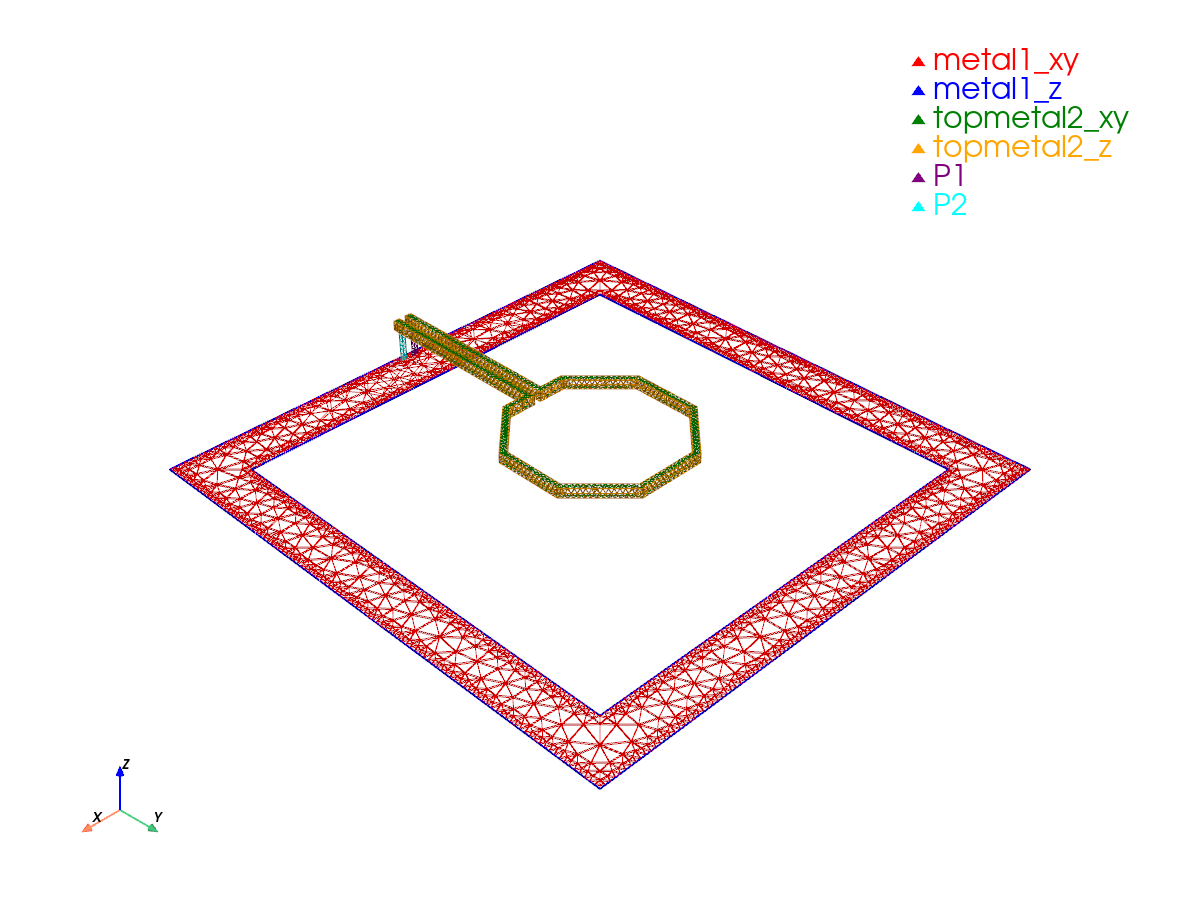

In [5]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)

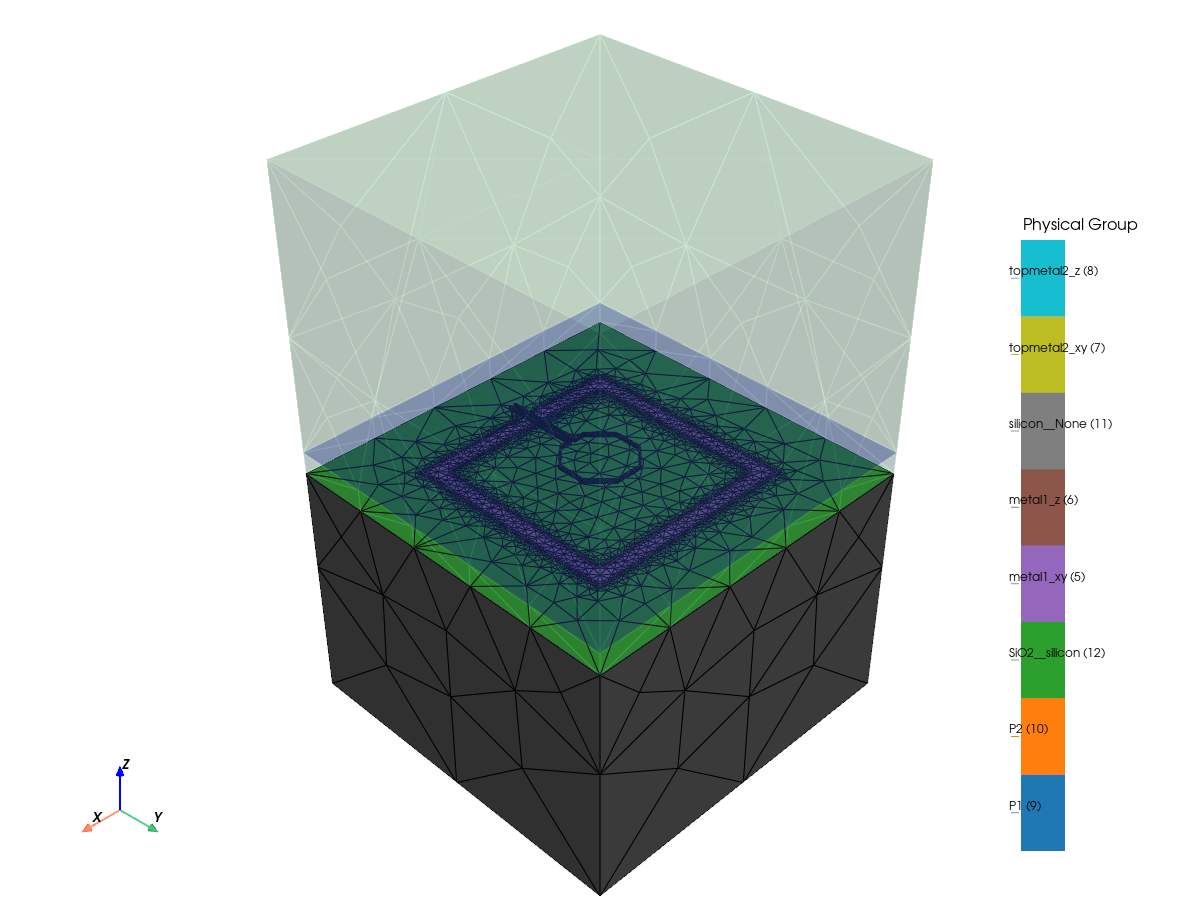

In [6]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [7]:
results = sim.run(parent_dir="runs/palace-sim-inductor-guardring")

  palace-cff39dfe  completed  3m 40s
Extracting results.tar.gz...
Downloaded 11 files to runs/palace-sim-inductor-guardring/sim-data-palace-cff39dfe


In [8]:
fig = results.plot_interactive()
fig.update_layout(title="Metal1 Guard Ring (Center Cutout)")
fig.show()

Port mapping: Port 1: P1, Port 2: P2


In [9]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2


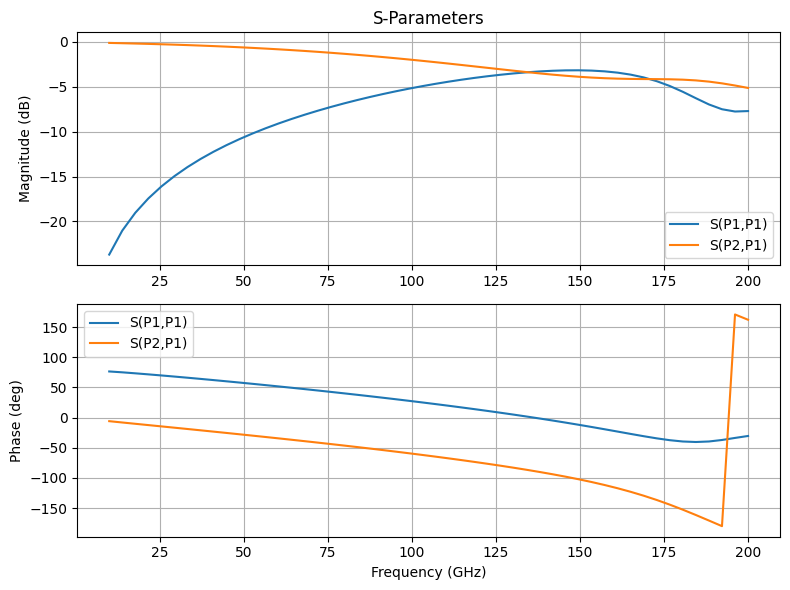

In [10]:
results.plot()

In [11]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

Build the Network from raw results 

In [12]:
f = results.freq * 1e9  # GHz → Hz
w = 2 * np.pi * f

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit='hz')
Z = ntwk.z
Y = ntwk.y

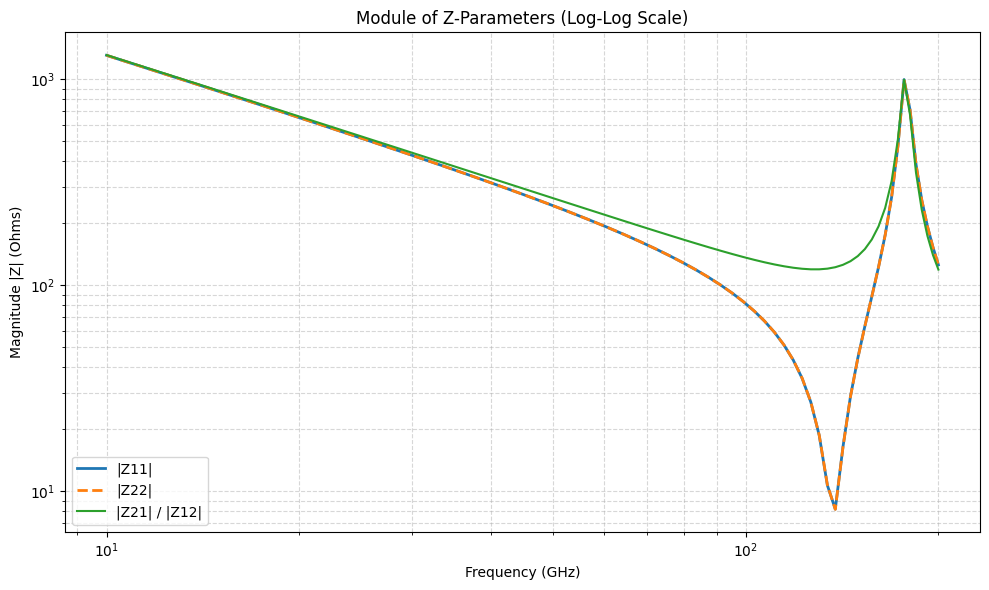

In [13]:
plt.figure(figsize=(10, 6))

# Calculate and plot the magnitude (module) of the complex Z-parameters
plt.plot(f / 1e9, np.abs(Z[:, 0, 0]), label='|Z11|', linewidth=2)
plt.plot(f / 1e9, np.abs(Z[:, 1, 1]), label='|Z22|', linestyle='--', linewidth=2)
plt.plot(f / 1e9, np.abs(Z[:, 1, 0]), label='|Z21| / |Z12|')

# Set Log-Log Scale
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude |Z| (Ohms)')
plt.title('Module of Z-Parameters (Log-Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Single-Ended Extraction (Port 2 Grounded)

In [14]:
Y11 = Y[:, 0, 0]
L_single = np.imag(1 / Y11) / w
Q_single = - np.imag(Y11) / np.real(Y11)

# Mask to find Peak Q only in the inductive region (before SRF)
mask = L_single > 0
idx_se = np.argmax(Q_single[mask])
f_masked_se = f[mask]

print(f"L @ 1 GHz  = {L_single[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_single[mask][idx_se]:.1f} @ {f_masked_se[idx_se]/1e9:.1f} GHz")

L @ 1 GHz  = 135.1 pH
Peak Q     = 15.7 @ 64.3 GHz


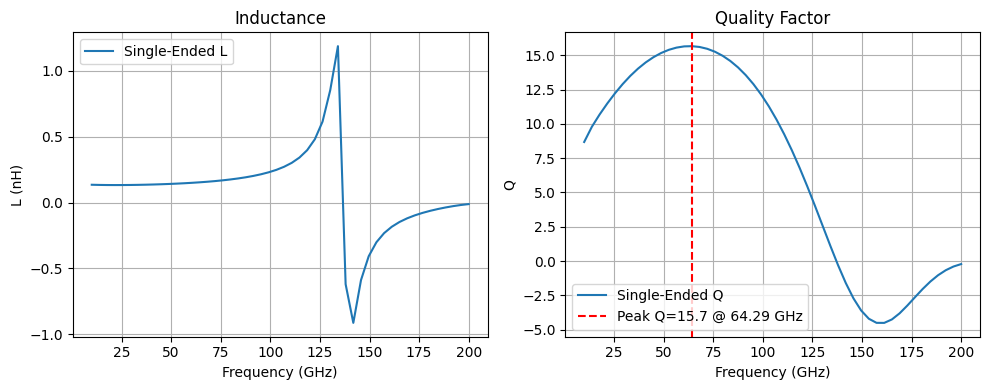

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_single * 1e9, label='Single-Ended L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_single, label='Single-Ended Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_se[idx_se]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_single[idx_se]:.1f} @ {f_masked_se[idx_se]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Intrinsic Series Extraction (from Y21)

In [16]:
Y21 = Y[:, 1, 0] # or Y[:, 0, 1] for Y12

# Convert series admittance back to series impedance
# The negative sign is required because Y21 = -Y_series
Z_series = -1 / Y21
Q_series = np.imag(Z_series) / np.real(Z_series)
L_series = np.imag(Z_series) / w

mask = L_series > 0
idx_series = np.argmax(Q_series[mask])
f_masked_series = f[mask]

print(f"L @ 1 GHz  = {L_series[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_series[mask][idx_series]:.1f} @ {f_masked_series[idx_series]/1e9:.1f} GHz")

L @ 1 GHz  = 134.6 pH
Peak Q     = 1504.1 @ 145.7 GHz


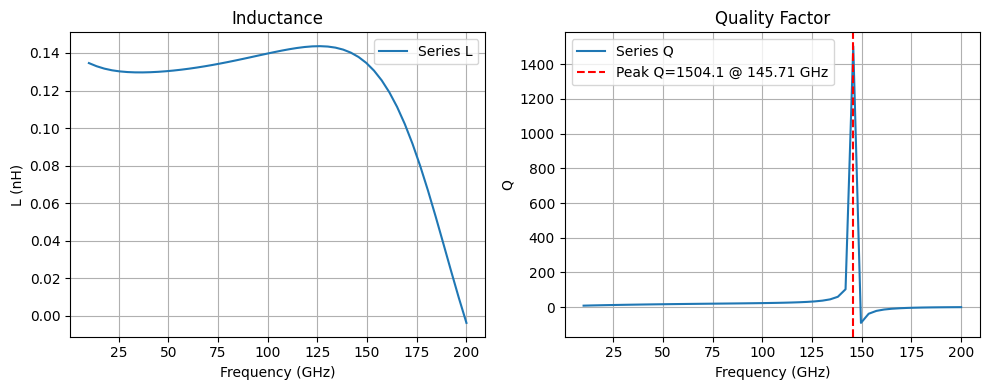

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_series * 1e9, label='Series L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_series, label='Series Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_series[idx_series]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_series[idx_series]:.1f} @ {f_masked_series[idx_series]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Differential Extraction (Push-Pull)

In [18]:
Z_diff = Z[:, 0, 0] + Z[:, 1, 1] - Z[:, 0, 1] - Z[:, 1, 0]
L_diff = (np.imag(Z_diff) / w) 
Q_diff = np.imag(Z_diff) / np.real(Z_diff)

mask = L_diff > 0
idx_diff = np.argmax(Q_diff[mask])
f_masked_diff = f[mask]

print(f"L @ 1 GHz  = {L_diff[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_diff[mask][idx_diff]:.1f} @ {f_masked_diff[idx_diff]/1e9:.1f} GHz")

L @ 1 GHz  = 134.8 pH
Peak Q     = 17.8 @ 83.7 GHz


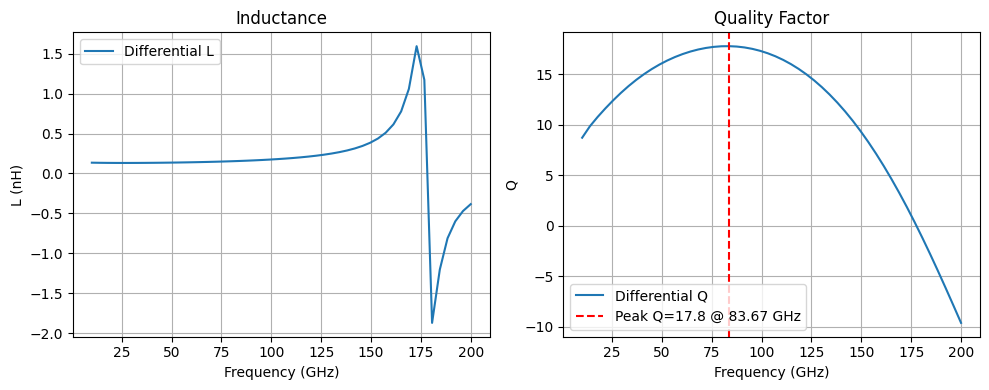

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_diff * 1e9, label='Differential L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_diff, label='Differential Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_diff[idx_diff]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_diff[mask][idx_diff]:.1f} @ {f_masked_diff[idx_diff]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

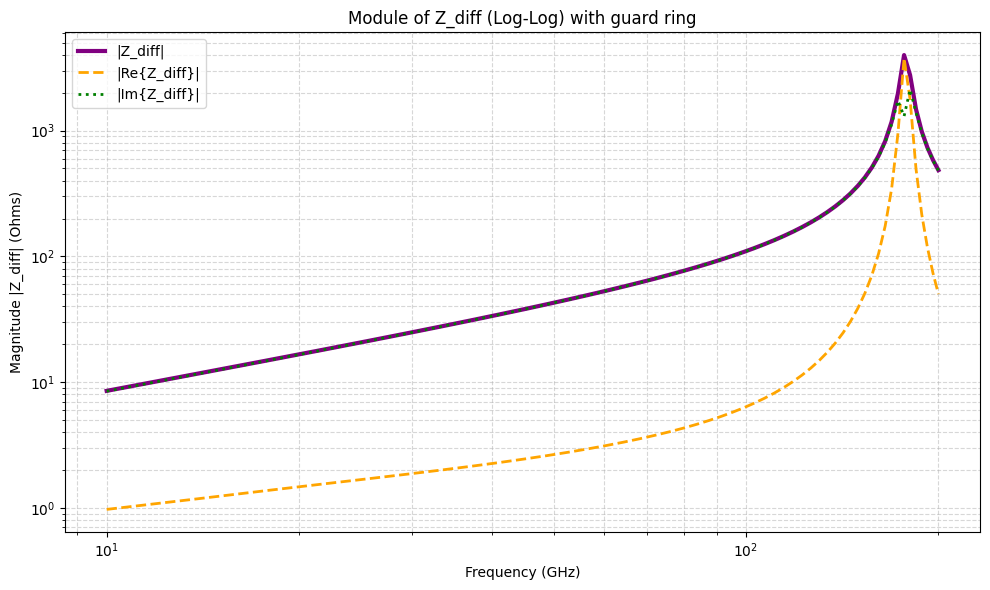

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(f / 1e9, np.abs(Z_diff), label='|Z_diff|', color='purple', linewidth=3)
plt.plot(f / 1e9, np.abs(np.real(Z_diff)), label='|Re{Z_diff}|', color='orange', linestyle='--', linewidth=2)
plt.plot(f / 1e9, np.abs(np.imag(Z_diff)), label='|Im{Z_diff}|', color='green', linestyle=':', linewidth=2)


plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude |Z_diff| (Ohms)')
plt.title('Module of Z_diff (Log-Log) with guard ring')
plt.legend()

plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Inductor Compact Model: Simulation Data → Polynomial Fit → SAX Circuit

In [21]:
import sax
import jax.numpy as jnp

In [22]:
# 1. Fit the Polynomials to the Data
degree = 5
poly_s11_re = np.polyfit(f, np.real(S[:, 0, 0]), degree)
poly_s11_im = np.polyfit(f, np.imag(S[:, 0, 0]), degree)
poly_s21_re = np.polyfit(f, np.real(S[:, 1, 0]), degree)
poly_s21_im = np.polyfit(f, np.imag(S[:, 1, 0]), degree)
poly_s22_re = np.polyfit(f, np.real(S[:, 1, 1]), degree)
poly_s22_im = np.polyfit(f, np.imag(S[:, 1, 1]), degree)

# 2. Convert to JAX (The SAX Engine)
p_s11_re_jax = jnp.array(poly_s11_re)
p_s11_im_jax = jnp.array(poly_s11_im)
p_s21_re_jax = jnp.array(poly_s21_re)
p_s21_im_jax = jnp.array(poly_s21_im)
p_s22_re_jax = jnp.array(poly_s22_re)
p_s22_im_jax = jnp.array(poly_s22_im)

# 3. Create the Compact Model Function
# You give it a frequency, and it spits out the S-parameters instantly.
def my_inductor_model(f=10e9):
    s11 = jnp.polyval(p_s11_re_jax, f) + 1j * jnp.polyval(p_s11_im_jax, f)
    s21 = jnp.polyval(p_s21_re_jax, f) + 1j * jnp.polyval(p_s21_im_jax, f)
    s22 = jnp.polyval(p_s22_re_jax, f) + 1j * jnp.polyval(p_s22_im_jax, f)
    # Return the connections between port1 and port2
    return {
        ("port1", "port1"): s11,
        ("port2", "port1"): s21,
        ("port1", "port2"): s21,  # It's an inductor, so S12 is the same as S21
        ("port2", "port2"): s22,
    }

In [23]:
test_freq = 60e9  # 60 GHz
test_result = my_inductor_model(test_freq)

print(f"S21 at 60 GHz is: {test_result[('port2', 'port1')]}")

S21 at 60 GHz is: (0.7413343665532558-0.5137706725415289j)


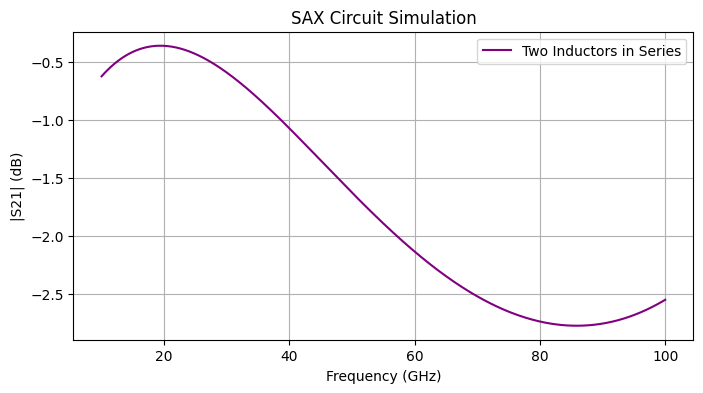

In [24]:
# 1. Register the model
# Tell sax that anytime we ask for "my_inductor", it should use your function
models = {
    "my_inductor": my_inductor_model
}

# 2. Write the Netlist (The Circuit Map)
netlist = {
    "instances": {
        "L1": "my_inductor",  # Put first inductor on the breadboard
        "L2": "my_inductor",  # Put second inductor on the breadboard
    },
    "connections": {
        # Wire Port 2 of L1 directly into Port 1 of L2
        "L1,port2": "L2,port1",  
    },
    "ports": {
        # Place our global measurement probes
        "in": "L1,port1",    
        "out": "L2,port2",   
    }
}

# 3. Compile and Simulate
my_circuit_fn, info = sax.circuit(netlist=netlist, models=models)

# Create an array of frequencies to test (10 GHz to 100 GHz)
f_sweep = jnp.linspace(10e9, 100e9, 500)
S_total = my_circuit_fn(f=f_sweep)

# 4. Plot the Results
# Extract the total transmission (S21) from the global input to output
S21_total_mag = jnp.abs(S_total["out", "in"])
S21_total_db = 20 * jnp.log10(S21_total_mag)

plt.figure(figsize=(8, 4))
plt.plot(f_sweep / 1e9, S21_total_db, label='Two Inductors in Series', color='purple')
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21| (dB)")
plt.title("SAX Circuit Simulation")
plt.grid(True)
plt.legend()
plt.show()

Fitting degree-5 polynomials to 2×2 S-matrix …


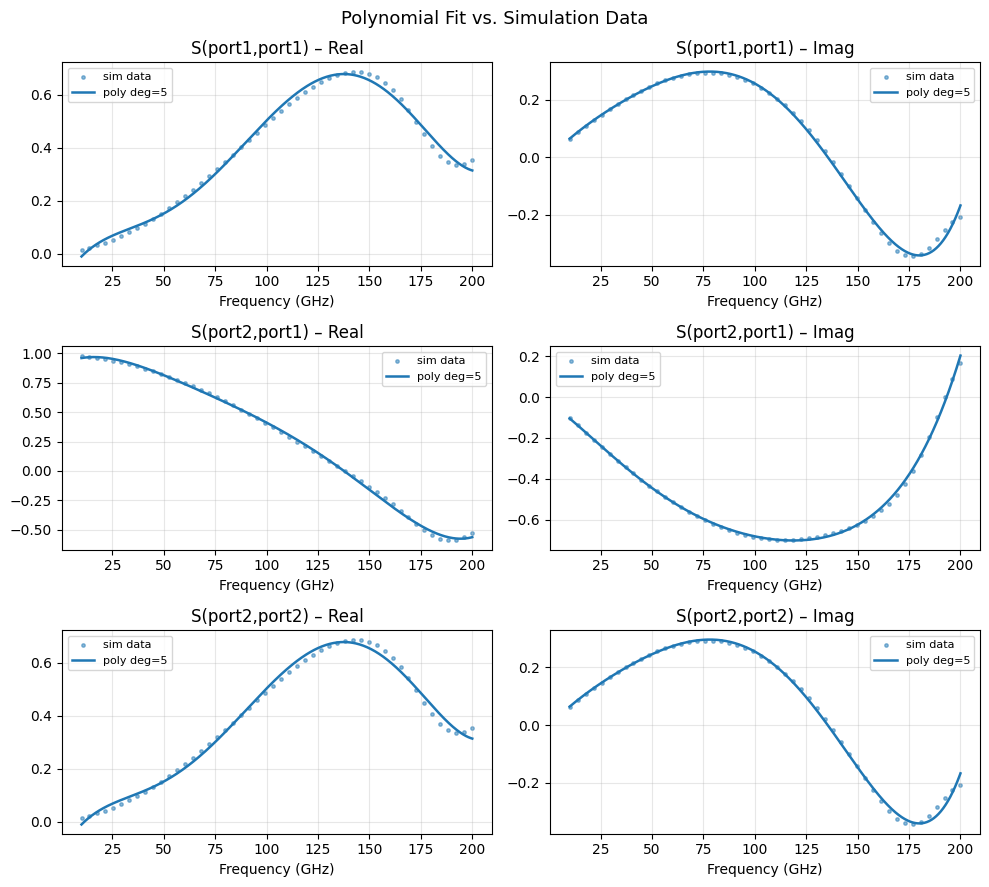


Model self-test at 60 GHz:
  S('port1', 'port1') = 0.2015+0.2743j
  S('port1', 'port2') = 0.7413-0.5138j
  S('port2', 'port1') = 0.7413-0.5138j
  S('port2', 'port2') = 0.2015+0.2743j


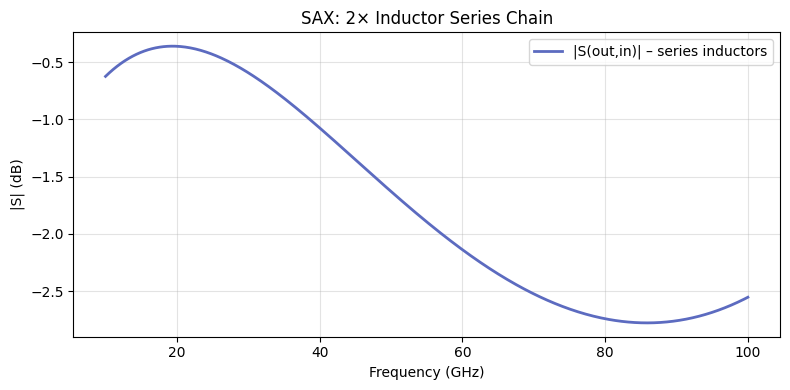

In [25]:
import sys
sys.path.append("~/gsim/nbs/IHP_components")

from inductor_compact_model import run_inductor_workflow

model, circuit_fn, S_total = run_inductor_workflow(results, degree=5, n_stages=2)